# 🚦 Smart City Traffic Analytics & Accident Prediction Dashboard

## Phase 2: Data Understanding

### 📌 Project Overview

This project analyzes traffic accident data across the United States to identify accident hotspots, understand contributing factors, predict accident severity, and build an executive Power BI dashboard for data-driven decision making.

---

### 🎯 Business Problem

Traffic accidents cause significant loss of life, injuries, and economic damage. City authorities need a system to:

- Identify accident hotspots
- Understand accident causes
- Analyze weather and road conditions
- Predict accident severity
- Support road safety decisions

---

### 🎯 Project Objectives

- Understand the dataset
- Assess data quality
- Identify missing values
- Explore important variables
- Prepare the data for analysis

In [5]:
# ==========================================================
# Smart City Traffic Analytics & Accident Prediction Dashboard
# Notebook : 01_Data_Understanding
# Author   : Nikhil Wadkar
# ==========================================================

# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

# Display all columns
pd.set_option("display.max_columns", None)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [6]:
# Load the dataset

df = pd.read_csv("../Data/Raw/US_Accidents_March23_sampled_500k.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [7]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,Accident on LA-19 Baker-Zachary Hwy at Lower Z...,Highway 19,Zachary,East Baton Rouge,LA,70791-4610,US,US/Central,KBTR,2019-06-12 09:53:00,77.0,77.0,62.0,29.92,10.0,NW,5.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,Incident on FOREST RIDGE DR near PEPPERIDGE PL...,Forest Ridge Dr,Sterling,Loudoun,VA,20164-2813,US,US/Eastern,KIAD,2022-12-03 23:52:00,45.0,43.0,48.0,29.91,10.0,W,5.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,Accident on W Central Ave from Floradale Ave t...,Floradale Ave,Lompoc,Santa Barbara,CA,93436,US,US/Pacific,KLPC,2022-08-20 12:56:00,68.0,68.0,73.0,29.79,10.0,W,13.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,Incident on I-90 EB near REST AREA Drive with ...,14th St NW,Austin,Mower,MN,55912,US,US/Central,KAUM,2022-02-21 17:35:00,27.0,15.0,86.0,28.49,10.0,ENE,15.0,0.0,Wintry Mix,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,RP ADV THEY LOCATED SUSP VEH OF 20002 - 726 CR...,River Blvd,Bakersfield,Kern,CA,93305-2649,US,US/Pacific,KBFL,2020-12-04 01:54:00,42.0,42.0,34.0,29.77,10.0,CALM,0.0,0.0,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night


In [8]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 500,000
Columns : 46


## 📌 Dataset Information

This section provides an overview of the dataset including:

- Number of observations
- Number of columns
- Data types
- Missing values
- Memory usage

Understanding the dataset structure helps identify data quality issues before performing analysis.

In [9]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  str    
 1   Source                 500000 non-null  str    
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  str    
 4   End_Time               500000 non-null  str    
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                279623 non-null  float64
 8   End_Lng                279623 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            499999 non-null  str    
 11  Street                 499309 non-null  str    
 12  City                   499981 non-null  str    
 13  County                 500000 non-null  str    
 14  State                  500000 non-null  str    

In [10]:
# Count each datatype

df.dtypes.value_counts()

str        20
bool       13
float64    12
int64       1
Name: count, dtype: int64

## 📌 Statistical Summary

This section summarizes the numerical columns by calculating:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [11]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,279623.000000,279623.000000,500000.000000,489534.000000,370983.000000,488870.000000,491072.000000,488709.000000,463013.000000,357384.000000
mean,2.212748,36.206421,-94.736583,36.273192,-95.776553,0.564317,61.646254,58.229028,64.834921,29.536621,9.091540,7.681347,0.008289
std,0.486661,5.071411,17.405761,5.265333,18.120211,1.774872,19.000133,22.352246,22.826158,1.008666,2.708083,5.431361,0.101865
min,1.000000,24.562117,-124.497420,24.570110,-124.497419,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.416823,-117.233047,33.474773,-117.778324,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.832147,-87.794365,36.192669,-88.039013,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.082443,-80.359601,40.181341,-80.252449,0.465000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.999569,-67.484130,48.998901,-67.484130,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000


In [12]:
df.describe(include="object")

C:\Users\Nikhil\AppData\Local\Temp\ipykernel_21440\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,500000,500000,500000,500000,499999,499309,499981,500000,500000,499884,500000,499493,498554,492326,488803,488899,498517,498517,498517,498517
unique,500000,3,487027,493821,408146,88272,9488,1606,49,127804,1,4,1878,255623,24,108,2,2,2,2
top,A-2047758,Source1,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-95 N,Miami,Los Angeles,CA,91761,US,US/Eastern,KCQT,2022-03-13 01:53:00,CALM,Fair,Day,Day,Day,Day
freq,1,279623,20,11,592,4973,12141,34247,113274,720,500000,231397,7756,92,62259,166053,344967,368274,392866,412242


## 📌 Missing Value Analysis

Missing values reduce data quality and can affect machine learning models.

This section identifies columns containing missing values and their percentages.

In [14]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing / len(df))*100,2)
})

missing_df

,Missing Values,Percentage
End_Lat,220377,44.08
End_Lng,220377,44.08
Precipitation(in),142616,28.52
Wind_Chill(F),129017,25.80
Wind_Speed(mph),36987,7.40
Visibility(mi),11291,2.26
Wind_Direction,11197,2.24
Humidity(%),11130,2.23
Weather_Condition,11101,2.22
Temperature(F),10466,2.09


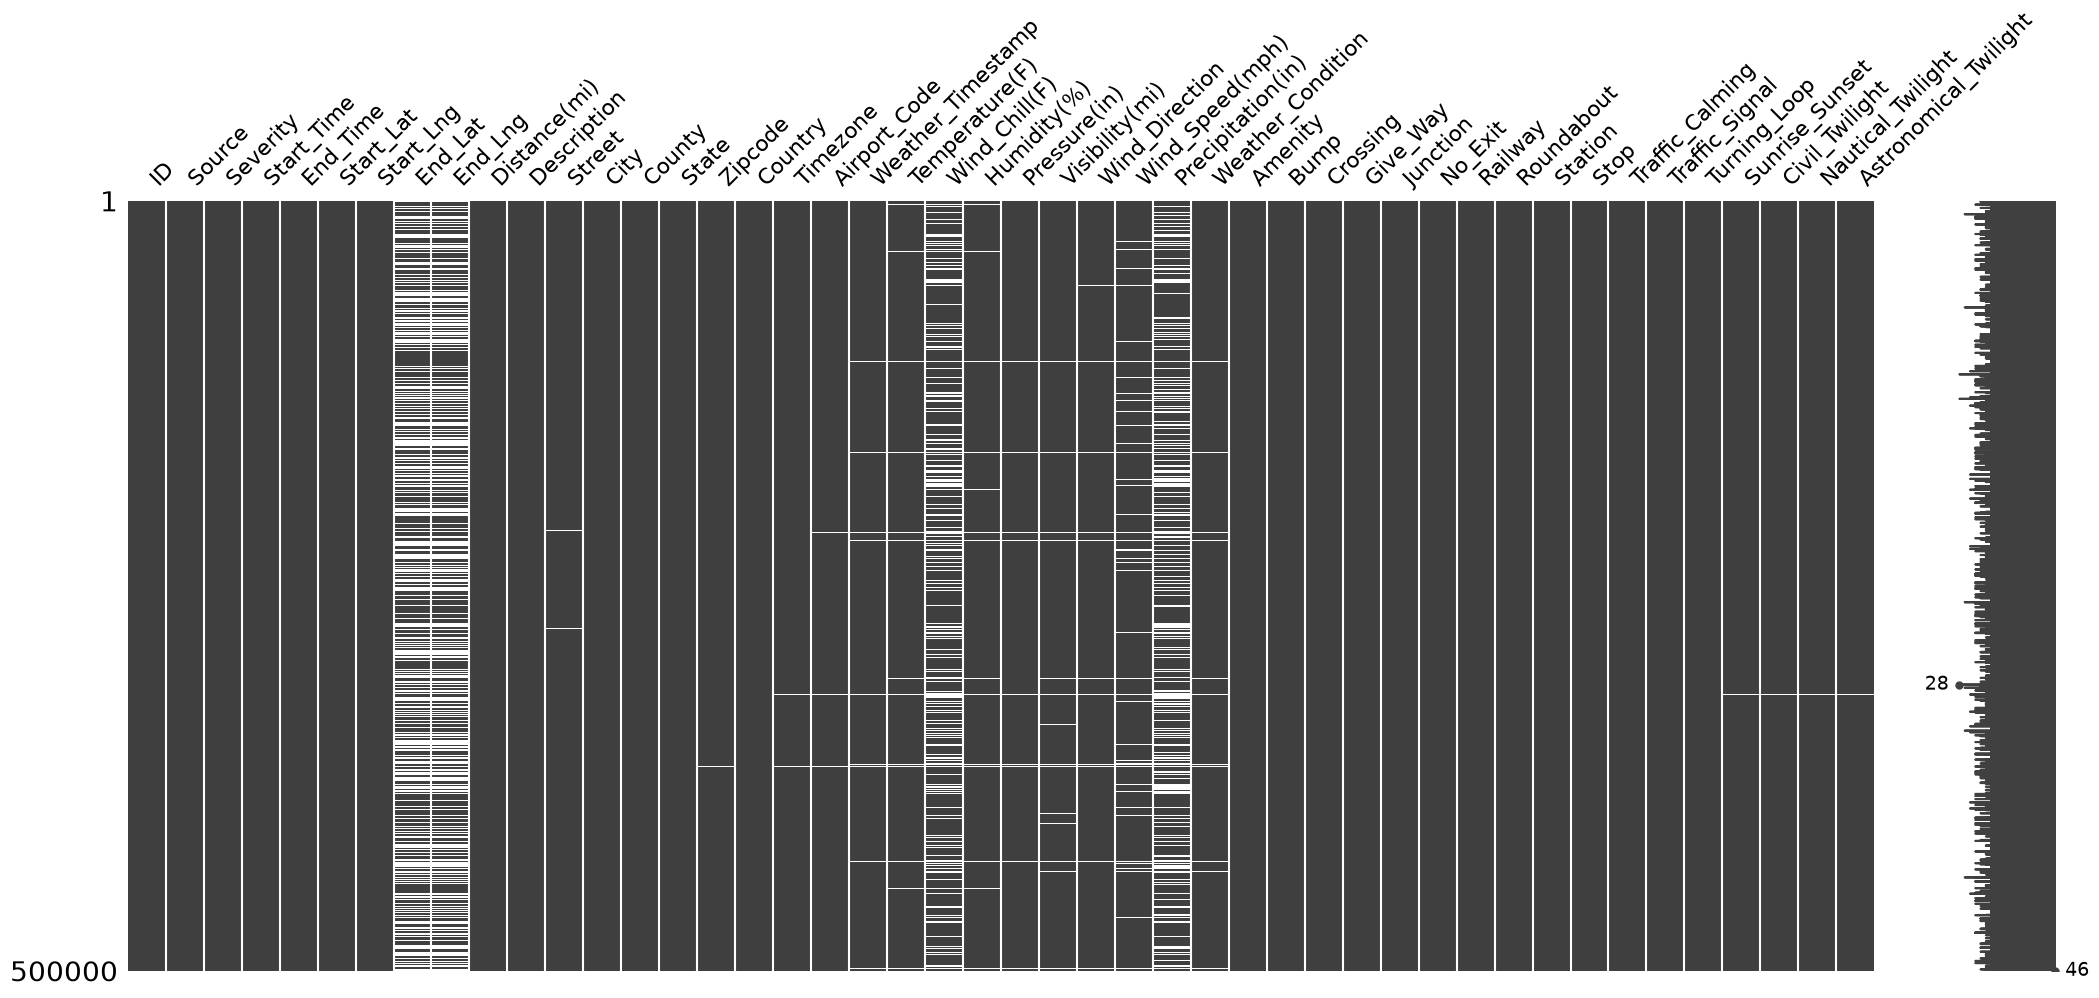

In [15]:
import missingno as msno

msno.matrix(df)
plt.show()

In [16]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

missing

End_Lng                  220377
End_Lat                  220377
Precipitation(in)        142616
Wind_Chill(F)            129017
Wind_Speed(mph)           36987
Visibility(mi)            11291
Wind_Direction            11197
Humidity(%)               11130
Weather_Condition         11101
Temperature(F)            10466
Pressure(in)               8928
Weather_Timestamp          7674
Sunrise_Sunset             1483
Civil_Twilight             1483
Astronomical_Twilight      1483
Nautical_Twilight          1483
Airport_Code               1446
Street                      691
Timezone                    507
Zipcode                     116
City                         19
Description                   1
dtype: int64

In [17]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

missing_percent.round(2)

End_Lng                  44.08
End_Lat                  44.08
Precipitation(in)        28.52
Wind_Chill(F)            25.80
Wind_Speed(mph)           7.40
Visibility(mi)            2.26
Wind_Direction            2.24
Humidity(%)               2.23
Weather_Condition         2.22
Temperature(F)            2.09
Pressure(in)              1.79
Weather_Timestamp         1.53
Sunrise_Sunset            0.30
Civil_Twilight            0.30
Astronomical_Twilight     0.30
Nautical_Twilight         0.30
Airport_Code              0.29
Street                    0.14
Timezone                  0.10
Zipcode                   0.02
City                      0.00
Description               0.00
dtype: float64

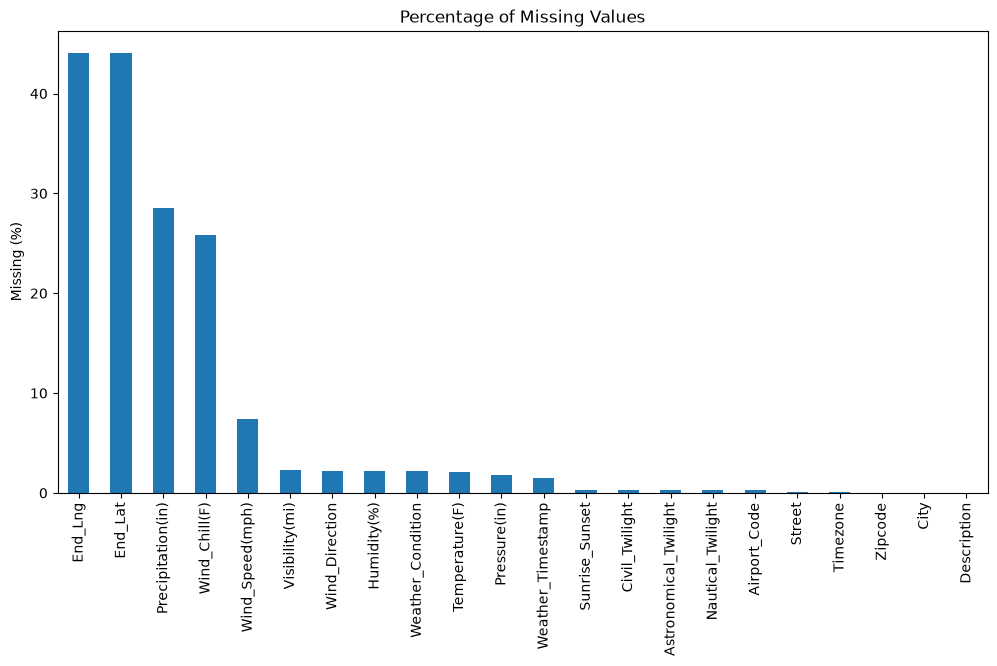

In [18]:
plt.figure(figsize=(12,6))

missing_percent.plot(kind="bar")

plt.title("Percentage of Missing Values")

plt.ylabel("Missing (%)")

plt.show()

In [19]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,279623.000000,279623.000000,500000.000000,489534.000000,370983.000000,488870.000000,491072.000000,488709.000000,463013.000000,357384.000000
mean,2.212748,36.206421,-94.736583,36.273192,-95.776553,0.564317,61.646254,58.229028,64.834921,29.536621,9.091540,7.681347,0.008289
std,0.486661,5.071411,17.405761,5.265333,18.120211,1.774872,19.000133,22.352246,22.826158,1.008666,2.708083,5.431361,0.101865
min,1.000000,24.562117,-124.497420,24.570110,-124.497419,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.416823,-117.233047,33.474773,-117.778324,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.832147,-87.794365,36.192669,-88.039013,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.082443,-80.359601,40.181341,-80.252449,0.465000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.999569,-67.484130,48.998901,-67.484130,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000
